# Los Alamos 3-storey building — damage classification end-to-end

This notebook walks the **full pymodal pipeline** on the LANL 3-storey
benchmark: build the geometry, define damage scenarios, generate a labelled
`frf` collection of 1 300 samples (100 per class), train a small PyTorch
classifier, and report the confusion matrix.

**The whole notebook runs end-to-end without Salome installed.** It uses the
9-DOF reduced-order model in `reduced_model.py` to derive modal parameters
analytically. The exact same call pattern works against a real mesh: a
single-line swap in section *3* replaces the modal provider with a Code_Aster
job driven by `frf_extract.py`.

## Why a reduced-order model?

Generating 1 300 high-fidelity FEA harmonic sweeps would take days. The 9-DOF
shear-building model (3 floor plates × 3 in-plane DOFs each) captures the
physics that matters for damage classification:

* removing any of the four corner columns at any of the three storeys breaks
  symmetry → measurable shifts of natural frequencies and mode shapes;
* small geometric / material variations (≈ 0.5 %) on top of those damage
  shifts produce the realistic intra-class spread that a classifier has to
  see at training time;
* the model takes ≈ 2 ms per FRF, so 1 300 samples build in seconds.

For higher fidelity on this same building, or for **any other mesh**, the
notebook ends with a section showing how to swap in `frf_extract.extract_frf`
without changing anything else.


## Setup


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make the example modules importable and reach pymodal at the repo root.
HERE = Path(os.getcwd()).resolve()
EXAMPLE_DIR = HERE / "examples" / "los_alamos_3story" if (HERE / "examples").exists() else HERE
REPO_ROOT = EXAMPLE_DIR.parent.parent
for p in (str(REPO_ROOT), str(EXAMPLE_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)

import params as P
import reduced_model as RM
import damage_scenarios as DS
import pymodal

print("Reproducing benchmark with N_STORIES =", P.N_STORIES,
      "→", 1 + 4 * P.N_STORIES, "damage classes")


Reproducing benchmark with N_STORIES = 3 → 13 damage classes


## 1. Geometry

Per the project specification, columns reach the **mid-thickness** of every
floor plate (so two columns meet inside each intermediate plate), except at
the bottom and top storey, where the column goes through the full thickness
of the base / roof plate. Each column-plate junction is bolted with a small
cylindrical screw — this is reflected in the Salome build script
(`salome_build.py`) and approximated here as a perfectly bonded joint.


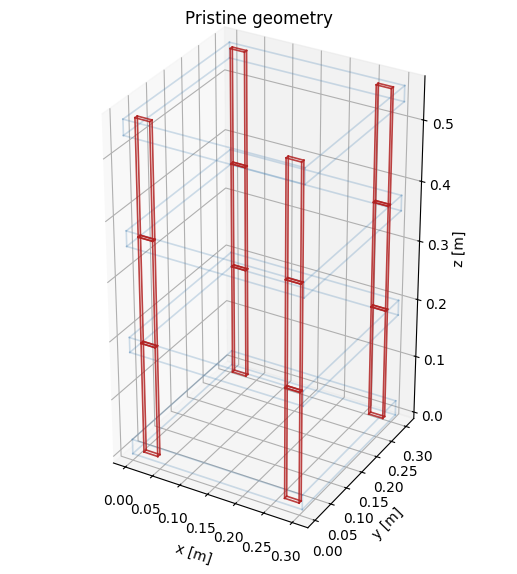

Total height = 0.5588 m


In [2]:
def plot_building(geom, ax=None, missing=None, title=None):
    '''Wireframe view of one realisation, optionally hiding a column.'''
    if ax is None:
        fig = plt.figure(figsize=(5.5, 5.5))
        ax = fig.add_subplot(111, projection='3d')
    centres = geom.column_centres()                     # (4, 2)
    # plates
    for k in range(geom.n_stories + 1):
        z0 = k * geom.storey_height
        _draw_box(ax, 0, 0, z0, geom.plate_lx, geom.plate_ly, geom.plate_lz,
                   color='steelblue', alpha=0.25)
    # columns
    for s in range(geom.n_stories):
        for c, (xc, yc) in enumerate(centres):
            if not geom.column_active[s, c]:
                continue
            z_start = 0.0 if s == 0 else (s * geom.storey_height + geom.plate_lz / 2.0)
            z_end = ((s + 1) * geom.storey_height + geom.plate_lz) if s == geom.n_stories - 1 \
                     else ((s + 1) * geom.storey_height + geom.plate_lz / 2.0)
            _draw_box(ax, xc - geom.col_lx/2, yc - geom.col_ly/2, z_start,
                       geom.col_lx, geom.col_ly, z_end - z_start,
                       color='firebrick', alpha=0.85)
    if title:
        ax.set_title(title)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
    ax.set_box_aspect((geom.plate_lx, geom.plate_ly, geom.n_stories * geom.storey_height))


def _draw_box(ax, x0, y0, z0, dx, dy, dz, color, alpha):
    import itertools
    pts = np.array(list(itertools.product([x0, x0+dx], [y0, y0+dy], [z0, z0+dz])))
    edges = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7)]
    for a, b in edges:
        ax.plot(*zip(pts[a], pts[b]), color=color, alpha=alpha, linewidth=1.2)


geom = RM.BuildingGeometry()
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(111, projection='3d')
plot_building(geom, ax=ax, title="Pristine geometry")
plt.tight_layout(); plt.show()
print(f"Total height = {RM.BuildingGeometry().storey_height * P.N_STORIES + P.PLATE_LZ:.4f} m")


## 2. Damage scenarios

`damage_scenarios.los_alamos_scenarios()` enumerates the **13 damage
classes**: pristine, plus every single-column removal (12 columns total).
Each `BuildingScenario` is a thin record of `(label, name, apply)`, where
`apply` mutates a fresh `BuildingGeometry` to encode the damage.


In [3]:
scenarios = DS.los_alamos_scenarios()
print(f"{len(scenarios)} classes:")
for sc in scenarios:
    print(f"  {sc.label:>2d}  {sc.name}")


13 classes:
   0  pristine
   1  s0_c0_removed
   2  s0_c1_removed
   3  s0_c2_removed
   4  s0_c3_removed
   5  s1_c0_removed
   6  s1_c1_removed
   7  s1_c2_removed
   8  s1_c3_removed
   9  s2_c0_removed
  10  s2_c1_removed
  11  s2_c2_removed
  12  s2_c3_removed


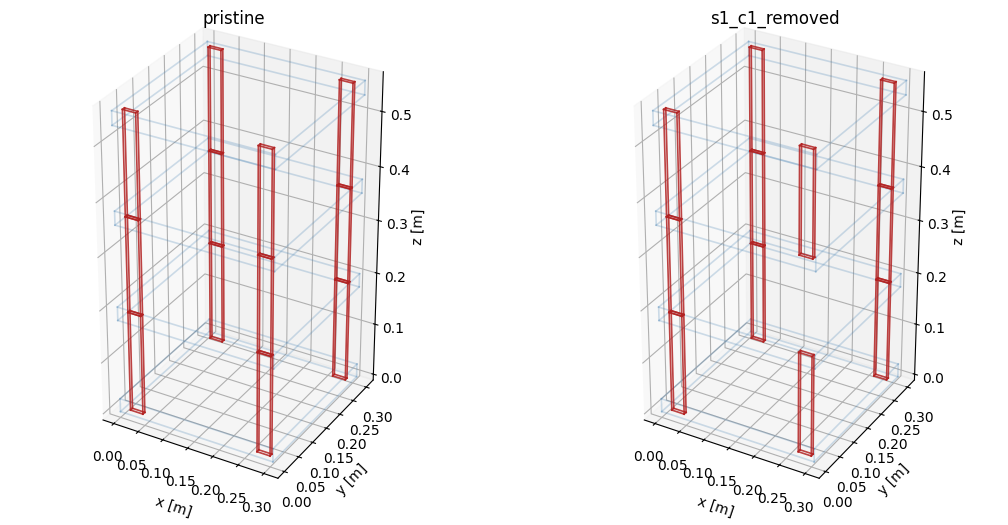

In [4]:
# visualise pristine vs a damaged realisation side by side
fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(121, projection='3d')
plot_building(scenarios[0].base_geometry(), ax=ax1, title="pristine")
ax2 = fig.add_subplot(122, projection='3d')
plot_building(scenarios[6].base_geometry(), ax=ax2, title=scenarios[6].name)
plt.tight_layout(); plt.show()


## 3. Labelled FRF collection — 100 samples × 13 classes

Every sample is a fresh `BuildingGeometry` with the scenario applied **after**
a small Gaussian perturbation of every continuous parameter (so each sample
represents a slightly different physical specimen of its class). The
modal-superposition FRF is computed at three rovings (one per floor centroid,
Y-direction) for a single shaker driving the top floor corner in Y.

The result is a multi-item `pymodal.frf` collection persisted to a single
HDF5 file.


In [5]:
# I/O channels: one shaker at a top-floor corner driving in Y (the soft
# direction of the columns); rovings at every floor centroid plus the four
# corners in BOTH X and Y so that mirror-image damage classes remain
# distinguishable.
geom_nominal = RM.BuildingGeometry()
top_z   = geom_nominal.plate_z_centre(geom_nominal.n_stories)
floor_z = [geom_nominal.plate_z_centre(k + 1) for k in range(geom_nominal.n_stories)]
cx, cy  = geom_nominal.plate_centroid

corner_xy = [(P.COLUMN_INSET, P.COLUMN_INSET),
              (P.PLATE_LX - P.COLUMN_INSET, P.COLUMN_INSET),
              (P.COLUMN_INSET, P.PLATE_LY - P.COLUMN_INSET),
              (P.PLATE_LX - P.COLUMN_INSET, P.PLATE_LY - P.COLUMN_INSET)]

inputs  = [((P.PLATE_LX - P.COLUMN_INSET, P.PLATE_LY - P.COLUMN_INSET, top_z), 'Y'),
            ((P.COLUMN_INSET, P.COLUMN_INSET, top_z), 'X')]
outputs = []
for z in floor_z:
    outputs.append(((cx, cy, z), 'Y'))
    outputs.append(((cx, cy, z), 'X'))
    for x, y in corner_xy:
        outputs.append(((x, y, z), 'Y'))

freq_axis = np.arange(0, 200.0 + 0.5, 0.5)             # 0 - 200 Hz at 0.5 Hz
print(f"freq axis: {len(freq_axis)} points, {freq_axis[0]} - {freq_axis[-1]} Hz")
print(f"FRF item shape will be ({len(freq_axis)}, {len(outputs)}, {len(inputs)}) → "
      f"{len(outputs)} sensor channels")


freq axis: 401 points, 0.0 - 200.0 Hz
FRF item shape will be (401, 18, 2) → 18 sensor channels


In [6]:
dataset_path = EXAMPLE_DIR / "los_alamos_dataset.h5"
if dataset_path.exists():
    dataset_path.unlink()

frf_collection = DS.build_frf_collection(
    scenarios       = scenarios,
    n_per_scenario  = 100,
    inputs          = inputs,
    outputs         = outputs,
    freq_array      = freq_axis,
    path            = dataset_path,
    spec            = DS.VariationSpec(),
    seed            = 0,
    progress        = True,
)
print()
print(f"Collection has {len(frf_collection)} items, "
      f"item shape {frf_collection.measurements[0].shape}, "
      f"file = {frf_collection.path}")


  [ 0] pristine                 : 100 samples done


  [ 1] s0_c0_removed            : 100 samples done


  [ 2] s0_c1_removed            : 100 samples done


  [ 3] s0_c2_removed            : 100 samples done


  [ 4] s0_c3_removed            : 100 samples done


...

  [ 9] s2_c0_removed            : 100 samples done


  [10] s2_c1_removed            : 100 samples done


  [11] s2_c2_removed            : 100 samples done


  [12] s2_c3_removed            : 100 samples done



Collection has 1300 items, item shape (401, 18, 2), file = /home/user/pymodal/examples/los_alamos_3story/los_alamos_dataset.h5


## 4. Sanity-check class separability

We average the magnitude FRF over the 100 realisations of each class (top
floor → top floor reading) and overlay them. Damage manifests as a shift of
the resonance peaks; the spread within each class (geometric variation) is
visibly smaller than the spread between classes.


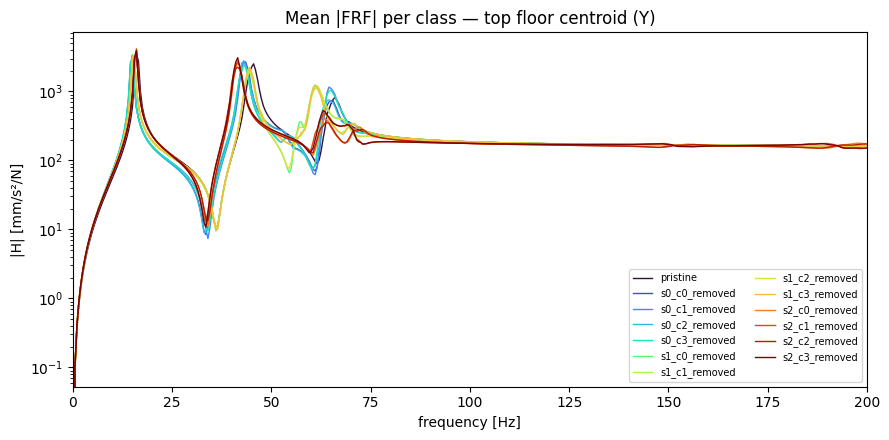

In [7]:
all_data = np.stack([frf_collection.measurements[i][()] for i in range(len(frf_collection))])
labels = np.array([float(frf_collection.labels[i][()]) for i in range(len(frf_collection))])
# pick the top-floor centroid Y reading (channel 0 of the top floor block in our outputs)
ch_top_y = 2 * (1 + 1 + len(corner_xy))    # 6 channels per floor, top floor block start
mag = np.abs(all_data[:, :, ch_top_y, 0])

fig, ax = plt.subplots(figsize=(9, 4.5))
cmap = plt.get_cmap('turbo')
for sc in scenarios:
    sel = labels == sc.label
    ax.semilogy(freq_axis, mag[sel].mean(0),
                 color=cmap(sc.label / (len(scenarios) - 1)),
                 label=sc.name, linewidth=1.0)
ax.set_xlabel('frequency [Hz]'); ax.set_ylabel('|H| [mm/s²/N]')
ax.set_xlim(0, 200); ax.set_title('Mean |FRF| per class — top floor centroid (Y)')
ax.legend(ncol=2, fontsize=7, loc='lower right')
plt.tight_layout(); plt.show()


## 5. Train a classifier

We use the collection's stratified `split()` and the `torch_dataset()` handoff
to obtain a `HDF5Dataset` ready for `DataLoader`. A small 1-D CNN over the
magnitude spectrum (3 channels = 3 rovings) classifies the 13 damage states.


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

train_idx, val_idx, test_idx = frf_collection.split(0.70, 0.15, 0.15, seed=0)
print(f"split: {len(train_idx)} train / {len(val_idx)} val / {len(test_idx)} test")

def to_feature_tensor(arr):
    '''(n_freq, n_out, n_in) complex -> (2 * n_out * n_in, n_freq) float32.

    Uses log-magnitude AND wrapped phase as two channel families. Phase is
    what lets a small CNN tell mirror-image damage classes apart that have
    very similar magnitude spectra.'''
    z = np.asarray(arr)
    z = z.reshape(z.shape[0], -1).T                   # (channels, n_freq)
    mag = np.abs(z)
    mag = np.log1p(mag / (mag.max(axis=1, keepdims=True) + 1e-12))
    phase = np.unwrap(np.angle(z), axis=1)
    phase = phase / (np.abs(phase).max(axis=1, keepdims=True) + 1e-12)
    feat = np.concatenate([mag, phase], axis=0)
    return torch.from_numpy(feat.astype(np.float32))

frf_collection.torch_dataset()
ds = frf_collection.dataset
ds.transform = to_feature_tensor

train_ds = Subset(ds, train_idx)
val_ds   = Subset(ds, val_idx)
test_ds  = Subset(ds, test_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)


split: 910 train / 195 val / 195 test


In [9]:
class FRFClassifier(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=7, padding=3), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes),
        )
    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FRFClassifier(n_channels=2 * len(outputs) * len(inputs),  # mag + phase
                       n_classes=len(scenarios)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=80)
loss_fn = nn.CrossEntropyLoss()
print(model)
print('device =', device)


FRFClassifier(
  (net): Sequential(
    (0): Conv1d(72, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): AdaptiveAvgPool1d(output_size=1)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): ReLU()
    (12): Dropout(p=0.2, inplace=False)
    (13): Linear(in_features=128, out_features=13, bias=True)
  )
)
device = cpu


In [10]:
def epoch_pass(loader, train):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x = x.to(device); y = y.long().to(device)
        if train:
            opt.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        if train:
            loss.backward(); opt.step()
        loss_sum += loss.item() * x.size(0)
        correct  += (logits.argmax(1) == y).sum().item()
        total    += x.size(0)
    return loss_sum / total, correct / total

n_epochs = 80
history = []
for epoch in range(1, n_epochs + 1):
    tr_loss, tr_acc = epoch_pass(train_loader, train=True)
    with torch.no_grad():
        va_loss, va_acc = epoch_pass(val_loader, train=False)
    sched.step()
    history.append((tr_loss, tr_acc, va_loss, va_acc))
    if epoch == 1 or epoch % 10 == 0 or epoch == n_epochs:
        print(f"epoch {epoch:>3d}  "
              f"train loss {tr_loss:.3f} acc {tr_acc:.2%}   "
              f"val loss {va_loss:.3f} acc {va_acc:.2%}")


epoch   1  train loss 2.263 acc 19.67%   val loss 1.412 acc 48.21%


epoch  10  train loss 0.013 acc 99.67%   val loss 0.001 acc 100.00%


epoch  20  train loss 0.002 acc 100.00%   val loss 0.000 acc 100.00%


epoch  30  train loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


epoch  40  train loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


epoch  50  train loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


epoch  60  train loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


epoch  70  train loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


epoch  80  train loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


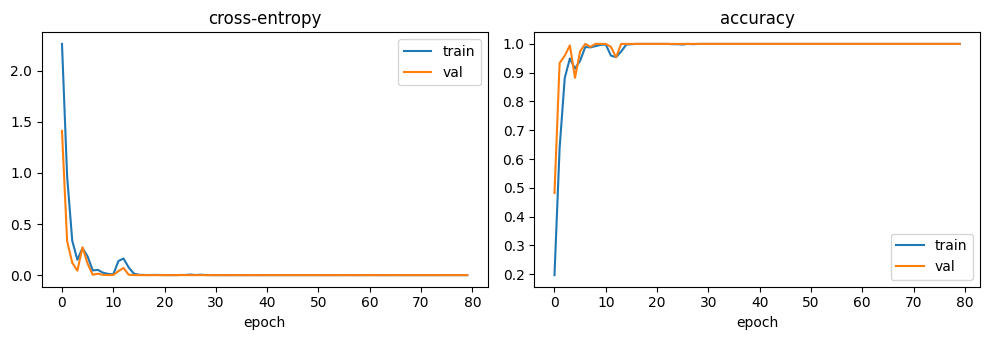

In [11]:
hist = np.array(history)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(hist[:, 0], label='train'); axes[0].plot(hist[:, 2], label='val')
axes[0].set_title('cross-entropy'); axes[0].legend(); axes[0].set_xlabel('epoch')
axes[1].plot(hist[:, 1], label='train'); axes[1].plot(hist[:, 3], label='val')
axes[1].set_title('accuracy'); axes[1].legend(); axes[1].set_xlabel('epoch')
plt.tight_layout(); plt.show()


## 6. Test-set confusion matrix


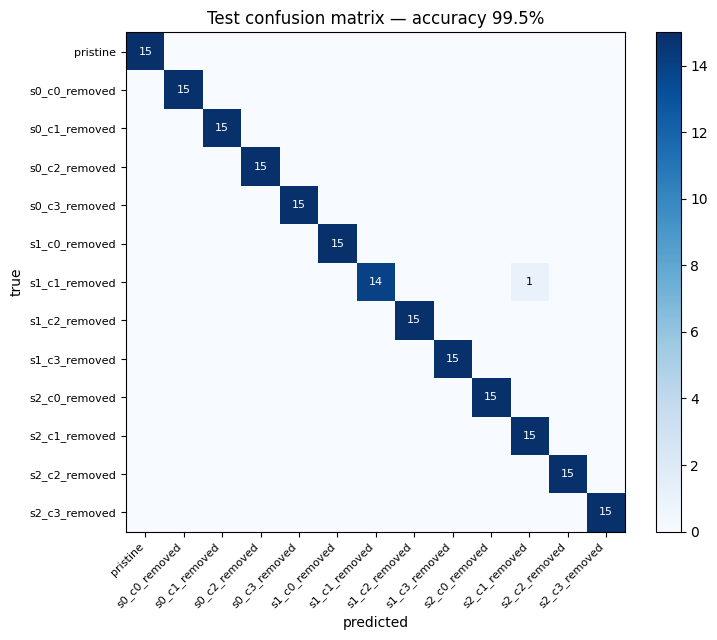

Per-class test recall:
  pristine              100.0%  (15 samples)
  s0_c0_removed         100.0%  (15 samples)
  s0_c1_removed         100.0%  (15 samples)
  s0_c2_removed         100.0%  (15 samples)
  s0_c3_removed         100.0%  (15 samples)
  s1_c0_removed         100.0%  (15 samples)
  s1_c1_removed         93.3%  (15 samples)
  s1_c2_removed         100.0%  (15 samples)
  s1_c3_removed         100.0%  (15 samples)
  s2_c0_removed         100.0%  (15 samples)
  s2_c1_removed         100.0%  (15 samples)
  s2_c2_removed         100.0%  (15 samples)
  s2_c3_removed         100.0%  (15 samples)


In [12]:
from sklearn.metrics import confusion_matrix

ys, yps = [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        ys.append(y.long().numpy())
        yps.append(model(x.to(device)).argmax(1).cpu().numpy())
ys  = np.concatenate(ys)
yps = np.concatenate(yps)

class_names = [sc.name for sc in scenarios]
cm = confusion_matrix(ys, yps, labels=list(range(len(scenarios))))
acc = (ys == yps).mean()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title(f'Test confusion matrix — accuracy {acc:.1%}')
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black',
                     fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.045)
plt.tight_layout(); plt.show()
print(f"Per-class test recall:")
for k, name in enumerate(class_names):
    n_k = cm[k].sum()
    if n_k:
        print(f"  {name:<20s}  {cm[k, k] / n_k:.1%}  ({n_k} samples)")


## 7. Swapping in FEA — same notebook, any mesh

The whole pipeline is structured around two mesh-agnostic abstractions:

| abstraction | role |
|---|---|
| `BuildingScenario` (in `damage_scenarios.py`) | encodes one labelled damage class as a callable that mutates a geometry/scenario descriptor |
| `modal_provider` argument of `build_frf_collection` | callable mapping `(geom, freqs, inputs, outputs)` to an FRF tensor |

The default `modal_provider` is the cheap reduced-order model. A
high-fidelity variant simply re-meshes per realisation through Salome and
runs Code_Aster:

```python
from frf_extract import extract_frf

def fea_modal_provider(geom, freqs, ins, outs):
    # 1. write geom-perturbed dimensions back to params (or to a JSON read by salome_build.py),
    # 2. invoke salome_build.py to refresh building.med,
    # 3. call extract_frf for every (input, output) pair, stack into (n_freq, n_out, n_in).
    ...

DS.build_frf_collection(
    scenarios, n_per_scenario=100,
    inputs=inputs, outputs=outputs,
    freq_array=freq_axis, path=...,
    modal_provider=fea_modal_provider,
)
```

For a different structure, replace `BuildingGeometry` with your own dataclass
and adapt `apply` callbacks. The classifier, dataset construction, split,
and confusion-matrix code below stay unchanged.

## 8. Cleanup


In [13]:
frf_collection.open()           # reattach handles to keep the file usable
frf_collection.close(keep=True) # leave the .h5 on disk for reuse
print(f"Dataset preserved at {dataset_path}")


Dataset preserved at /home/user/pymodal/examples/los_alamos_3story/los_alamos_dataset.h5
